 * @ Author: Yohei Ohto
 * @ Create Time: 2025-04-25 12:43:23
 * @ Modified time: 2025-08-15 17:39:10

- Compares the proportion of duplicate and common compounds across compound databases including SureChEMBL, DrugBank, MoleculeNet, and TDC using SMILES notation (a string representation of chemical structures).
- Visualizes the overlap of compounds between databases using Venn diagrams.
- Compares the registration dates (marketing start dates or patent dates) in SureChEMBL and DrugBank, presenting the results through scatter plots and histograms to determine which database registers compounds first.
- For each subdataset in MoleculeNet and TDC, visualizes the overlap with SureChEMBL and DrugBank using bar charts.
- These analyses reveal each database's coverage scope, differences in registration timing, and overlap rates with toxicology datasets.


In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import zipfile
import pubchempy as pcp
import os
import sys

current_dir = os.getcwd()
parent_parent_dir = os.path.dirname(os.path.dirname(current_dir))
src_dir = os.path.join(parent_parent_dir, 'src')
sys.path.append(src_dir)

from util import *

# surechembl vs drugbank

In [2]:
surechembl = pickle_load("../../data/processed/surechembl/250106_surechembl_smiles_date.pickle")
surechembl_smiles = set(surechembl.keys())

In [3]:
df_db = pd.read_csv("../../data/processed/drugbank/250106_drugbank_onlysmiles.csv")
drugbank_smiles = set(df_db["0"])

drugbank = pickle_load("../../data/processed/drugbank/250106_drugbank_smiles_date.pickle")
drugbank_smiles_with_date = set(drugbank.keys())

In [ ]:
from matplotlib_venn import venn3_unweighted

venn = venn3_unweighted([surechembl_smiles, drugbank_smiles, drugbank_smiles_with_date], ('surechembl', 'drugbank', 'drugbank with date'), alpha=0.7)

venn.get_patch_by_id('100').set_color('#ffcc6d')  
venn.get_patch_by_id('010').set_color('#6bedff')
venn.get_patch_by_id('001').set_color('#ff9684')

venn.get_patch_by_id('110').set_color('#aae577')  
venn.get_patch_by_id('101').set_color('#fff8bf')  
venn.get_patch_by_id('011').set_color('#e7d0f2')

venn.get_patch_by_id('111').set_color('#e2ddd0') 

In [5]:
from tqdm import tqdm
x_db = []
x_sc = []
for i in tqdm(surechembl_smiles):
    if i in drugbank_smiles_with_date:
        x_db.append(drugbank[i])
        x_sc.append(surechembl[i])

  0%|          | 0/23423951 [00:00<?, ?it/s]

100%|██████████| 23423951/23423951 [00:33<00:00, 707706.45it/s]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

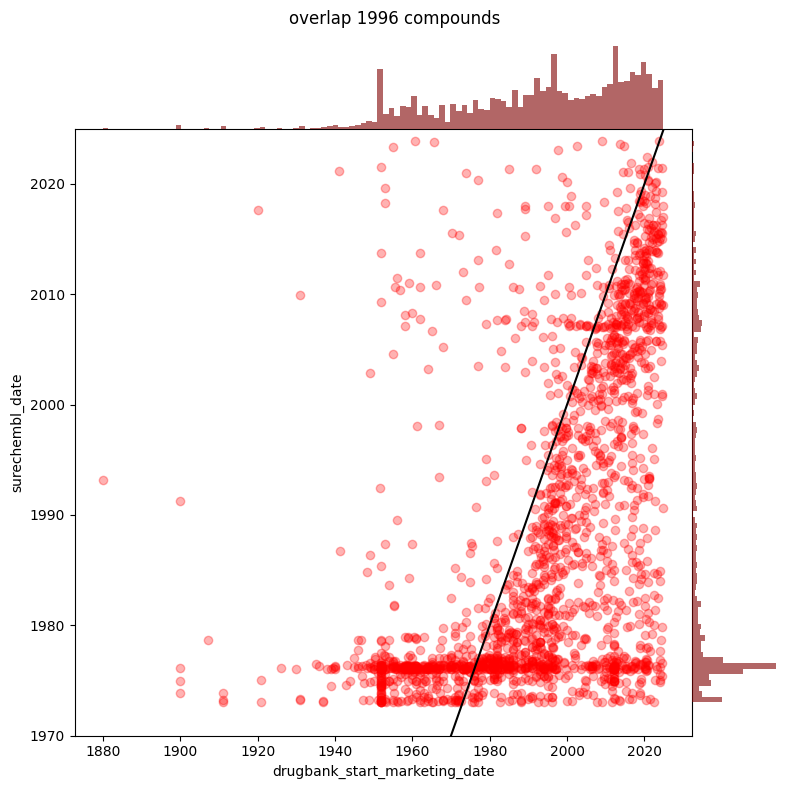

In [7]:
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(8, 8, figure=fig, wspace=0.0, hspace=0.0,)

scatter_ax = fig.add_subplot(gs[1:8, 0:7])
scatter_ax.scatter(x_db, x_sc, alpha=0.3, c="red")
x = np.linspace(1880, 2025 , 1000000)
y = x
scatter_ax.plot(x, y, c="black")
scatter_ax.set_ylim((1970,2025))
scatter_ax.set_xlabel('drugbank_start_marketing_date')
scatter_ax.set_ylabel("surechembl_date")

hist_x_ax = fig.add_subplot(gs[0, 0:7], sharex=scatter_ax)
hist_x_ax.hist(x_db, bins=100, alpha=0.6, color='maroon')
hist_x_ax.axis('off')

hist_y_ax = fig.add_subplot(gs[1:8, 7], sharey=scatter_ax)
hist_y_ax.hist(x_sc, bins=100, orientation='horizontal', alpha=0.6, color='maroon')
hist_y_ax.axis('off')

fig.suptitle(f"overlap {len(x_db)} compounds")
plt.tight_layout()
plt.savefig("../../data/result/fig5_overlap/fig1_surechembl_drugbank_overlap.png", dpi=300, bbox_inches='tight')

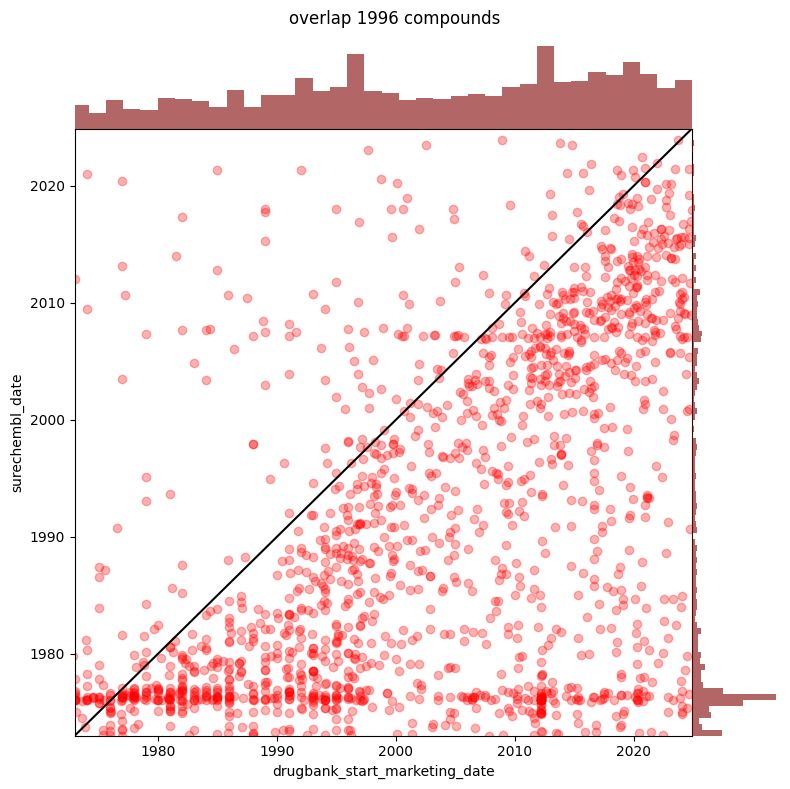

In [8]:
min_X = np.min(x_sc)

fig = plt.figure(figsize=(8, 8))
gs = GridSpec(8, 8, figure=fig, wspace=0.0, hspace=0.0,)

scatter_ax = fig.add_subplot(gs[1:8, 0:7])
scatter_ax.scatter(x_db, x_sc, alpha=0.3, c="red")

common_min = np.min(x_sc)
common_max = max(np.max(x_db), np.max(x_sc))

scatter_ax.set_xlim((common_min, common_max))
scatter_ax.set_ylim((common_min, common_max))

x_line = np.linspace(common_min, common_max, 100)
scatter_ax.plot(x_line, x_line, c="black")

scatter_ax.set_xlabel('drugbank_start_marketing_date')
scatter_ax.set_ylabel("surechembl_date")

hist_x_ax = fig.add_subplot(gs[0, 0:7], sharex=scatter_ax)
hist_x_ax.hist(x_db, bins=100, alpha=0.6, color='maroon')
hist_x_ax.axis('off')

hist_y_ax = fig.add_subplot(gs[1:8, 7], sharey=scatter_ax)
hist_y_ax.hist(x_sc, bins=100, orientation='horizontal', alpha=0.6, color='maroon')
hist_y_ax.axis('off')

fig.suptitle(f"overlap {len(x_db)} compounds")
plt.tight_layout()
plt.savefig("../../data/result/fig5_overlap/fig1_surechembl_drugbank_overlap_tiled.png", dpi=300, bbox_inches='tight')

In [ ]:
correlation = np.corrcoef(x_db, x_sc)[0, 1]
print(f"Correlation coefficient: {correlation:.4f}")

# rank correlation
from scipy.stats import rankdata
x_db_rank = rankdata(x_db)
x_sc_rank = rankdata(x_sc)
correlation = np.corrcoef(x_db_rank, x_sc_rank)[0, 1]
print(f"Spearman rank Correlation coefficient: {correlation:.4f}")

# Percentage of compounds whose patents were filed earlier, based on data from 1976 onward when US patent information began to be collected
filtered_indices = [i for i, x in enumerate(x_sc) if x > 1976]
smaller_count = sum(x_sc[i] < x_db[i] for i in filtered_indices)
total_count = len(filtered_indices)
smaller_ratio = smaller_count / total_count
print(f"Ratio of data where Shurechembl is faster than drugbank: {smaller_ratio:.4%}")

Correlation coefficient: 0.5317
Spearman順位相関係数: 0.5886
Ratio of data where Shurechembl is faster than drugbank: 72.3104%


In [ ]:
# which compounds are patented earlier in drugbank than Shurechembl?
earlier_in_db = [i for i in filtered_indices if x_sc[i] >= x_db[i]]
print(f"Number of compounds patented earlier in drugbank than Shurechembl: {len(earlier_in_db)}")

Number of compounds patented earlier in drugbank than Shurechembl: 471


In [ ]:
sc_and_db = []
for i in tqdm(surechembl_smiles):
    col = []
    if i in drugbank_smiles_with_date:
        col.append(i)
        col.append(surechembl[i])
        col.append(drugbank[i])
        sc_and_db.append(col)

  1%|          | 253240/23423951 [00:00<01:07, 341048.75it/s]

100%|██████████| 23423951/23423951 [00:33<00:00, 690545.56it/s]


In [ ]:
db_is_earlier = []
for smiles, sc, db in sc_and_db:
    if sc >= db:
        db_is_earlier.append([smiles, sc, db])

In [ ]:
dbs = [db for smiles, sc, db in sc_and_db]
print(min(dbs))

1880.003


In [ ]:
# show with rdkit
from rdkit import Chem
from rdkit.Chem import Draw

for i in range(len(db_is_earlier)):
    smiles, sc, db = db_is_earlier[i]
    if 1940 < db < 1950:
        print(smiles)
        img_smiles = smiles
        print("Drug approved", db)
        print("Patent published", sc)

COc1cc(NC(C)CCCN)c2ncccc2c1
Drug approved 1946.0
Patent published 1976.284
O=S(=O)([O-])c1ccc(N=Nc2c(O)ccc3ccccc23)cc1.[Na+]
Drug approved 1941.299
Patent published 1986.767
CN(C)CCN(Cc1ccccc1)c1ccccn1
Drug approved 1948.0
Patent published 1976.437
CN[C@@H](C)Cc1ccccc1
Drug approved 1944.0
Patent published 1974.981
Nc1ccc(C(=O)NCC(=O)O)cc1
Drug approved 1944.997
Patent published 1977.011
CN1C[C@H](C(=O)N[C@]2(C)O[C@@]3(O)[C@@H]4CCCN4C(=O)[C@H](Cc4ccccc4)N3C2=O)C[C@@H]2c3cccc4[nH]cc(c34)C[C@H]21
Drug approved 1947.0
Patent published 1975.422
CCCCOc1cc(C(=O)NCCN(CC)CC)c2ccccc2n1
Drug approved 1945.0
Patent published 1976.208
CN1C(=O)OC(C)(C)C1=O
Drug approved 1946.068
Patent published 1976.131
CCC(=O)C(CC(C)N(C)C)(c1ccccc1)c1ccccc1
Drug approved 1947.616
Patent published 1974.808
OC[C@H]1OC([S-])[C@H](O)[C@@H](O)[C@@H]1O.[Au+]
Drug approved 1941.0
Patent published 2021.192
COc1ccc2c3c1O[C@H]1C(=O)CC[C@H]4[C@@H](C2)N(C)CC[C@]314
Drug approved 1943.225
Patent published 1976.361
CN(C)CCOC(c

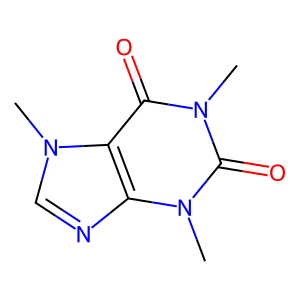

In [ ]:
img = Draw.MolToImage(Chem.MolFromSmiles(img_smiles))
img

# surechembl vs drugbank vs molculenet 

In [ ]:
# select 1 dataset from ../../data
df_mn_test = pd.read_csv("../../data/processed/moleculenet/moleculenet_patentdate/sider/pre_mol_dataset.tsv", sep="\t", header=None)

mn_test = dict()
for i in range(len(df_mn_test)):
    mn_test[df_mn_test.iloc[i,0]] = df_mn_test.iloc[i,1]

mn_test_smiles = set(mn_test.keys())

/root/.pyenv/versions/anaconda3-2024.10-1/envs/tmap/lib/python3.9/site-packages/matplotlib_venn/_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


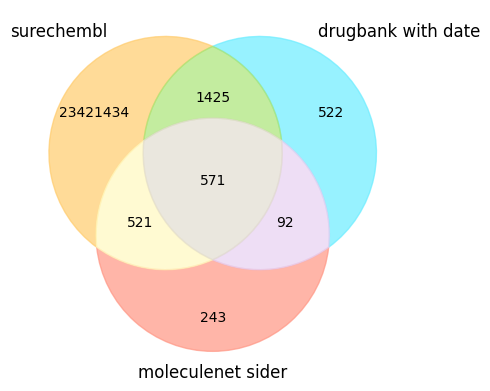

In [ ]:
venn = venn3_unweighted([surechembl_smiles, drugbank_smiles_with_date, mn_test_smiles], ('surechembl', 'drugbank with date', 'moleculenet sider'), alpha=0.7)

venn.get_patch_by_id('100').set_color('#ffcc6d')  
venn.get_patch_by_id('010').set_color('#6bedff')
venn.get_patch_by_id('001').set_color('#ff9684')

venn.get_patch_by_id('110').set_color('#aae577')  
venn.get_patch_by_id('101').set_color('#fff8bf')  
venn.get_patch_by_id('011').set_color('#e7d0f2')

venn.get_patch_by_id('111').set_color('#e2ddd0') 

In [ ]:
# about all dataset
import glob
paths = glob.glob("../../data/processed/moleculenet/moleculenet_patentdate/*/pre_mol_dataset.tsv")

overlap_db = []
overlap_sc = []
labels = []

for path in paths:
    df_mn_test = pd.read_csv(path, sep="\t", header=None)
    mn_smiles = set(df_mn_test[0])

    overlap_db.append(len(mn_smiles & drugbank_smiles) / len(mn_smiles) * 100)
    overlap_sc.append(len(mn_smiles & surechembl_smiles) / len(mn_smiles) * 100)
    labels.append(path.replace("../../data/processed/moleculenet/moleculenet_patentdate/", "").replace("/pre_mol_dataset.tsv", ""))

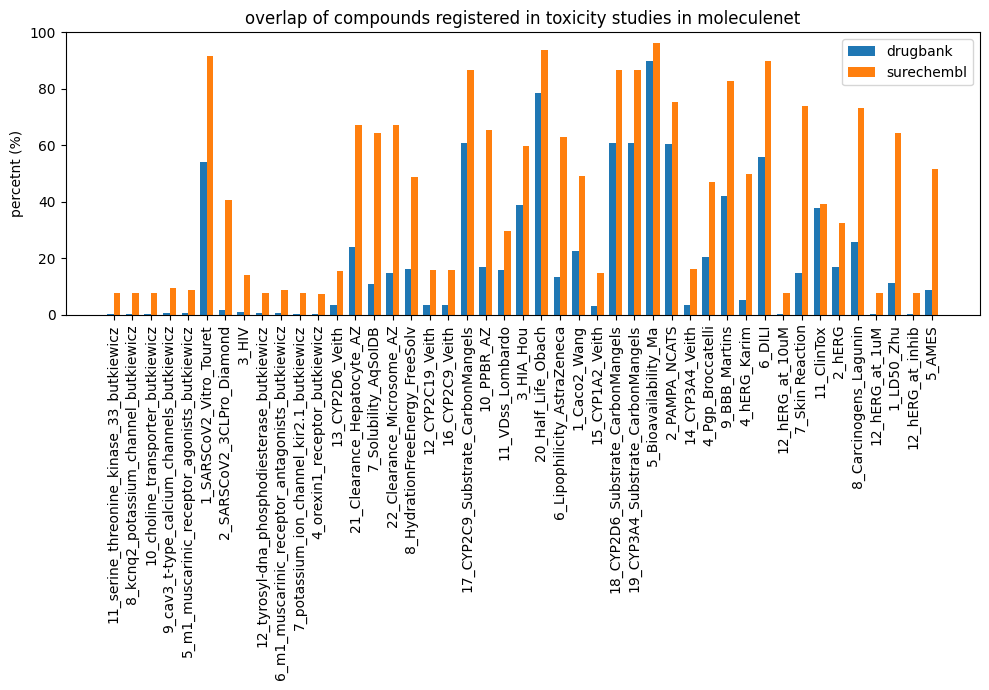

In [ ]:
x = np.arange(len(labels))
width = 0.35 

fig, ax = plt.subplots(figsize=(10,7))
rects1 = ax.bar(x - width/2, overlap_db, width, label='drugbank')
rects2 = ax.bar(x + width/2, overlap_sc, width, label='surechembl')

# ax.set_xlabel('Classes')
ax.set_ylabel('percetnt (%)')
ax.set_title('overlap of compounds registered in toxicity studies in moleculenet')
ax.set_xticks(x)
ax.set_ylim((0,100))
ax.set_xticklabels(labels, rotation=90)
ax.legend()

fig.tight_layout()
plt.savefig("../../data/result/fig1_overlap/moleculenet_overlap.png", dpi=300, bbox_inches='tight')

# surechembl vs drugbank vs tdc

In [ ]:
# select 1 dataset from ../../data
df_tdc_test = pd.read_csv("../../data/processed/tdc/Tox/4_hERG_Karim.tsv", sep="\t", index_col=0)

tdc_test = dict()
for i in range(len(df_tdc_test)):
    tdc_test[df_tdc_test.iloc[i,0]] = df_tdc_test.iloc[i,1]

tdc_test_smiles = set(tdc_test.keys())

/root/.pyenv/versions/anaconda3-2024.10-1/envs/tmap/lib/python3.9/site-packages/matplotlib_venn/_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


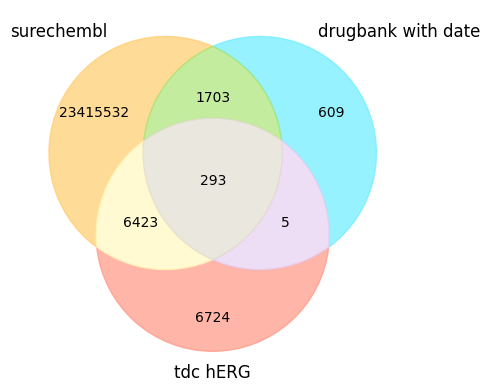

In [ ]:
from matplotlib_venn import venn3_unweighted
venn = venn3_unweighted([surechembl_smiles, drugbank_smiles_with_date, tdc_test_smiles], ('surechembl', 'drugbank with date', 'tdc hERG'), alpha=0.7)

venn.get_patch_by_id('100').set_color('#ffcc6d')  
venn.get_patch_by_id('010').set_color('#6bedff')
venn.get_patch_by_id('001').set_color('#ff9684')

venn.get_patch_by_id('110').set_color('#aae577')  
venn.get_patch_by_id('101').set_color('#fff8bf')  
venn.get_patch_by_id('011').set_color('#e7d0f2')

venn.get_patch_by_id('111').set_color('#e2ddd0') 

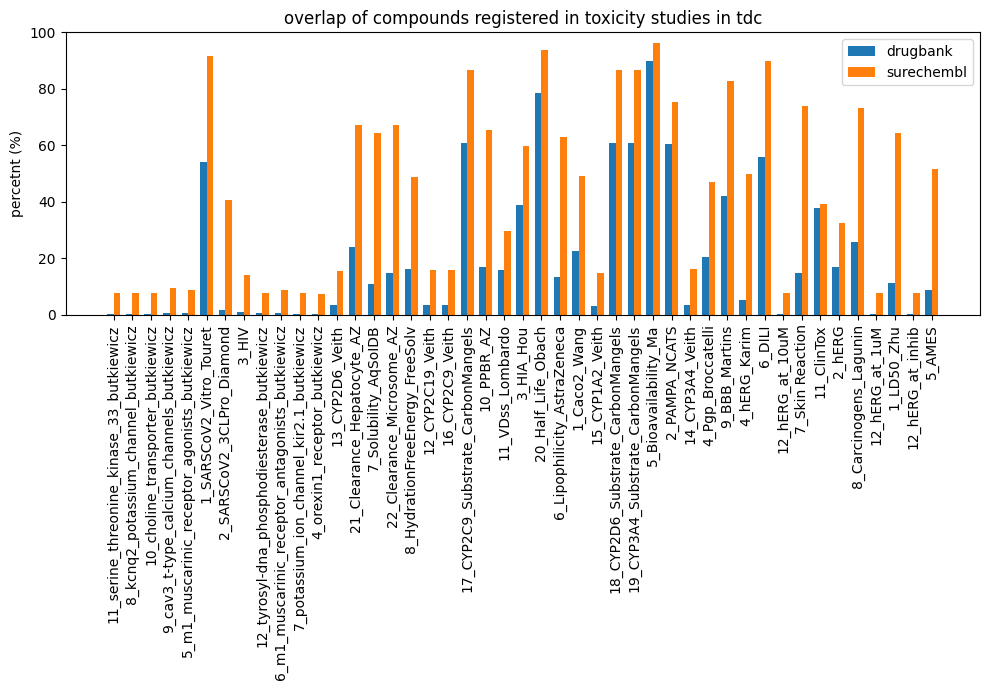

In [ ]:
# about full database

paths = glob.glob("../../data/processed/tdc/*/*.tsv")

overlap_db = []
overlap_sc = []
labels = []

for path in paths:
    if "_date" in path:
        continue
    df_mn_test = pd.read_csv(path, sep="\t", index_col=0)
    mn_smiles = set(df_mn_test["0"])

    overlap_db.append(len(mn_smiles & drugbank_smiles) / len(mn_smiles) * 100)
    overlap_sc.append(len(mn_smiles & surechembl_smiles) / len(mn_smiles) * 100)
    labels.append(path.replace("../../data/processed/tdc/", "").replace(".tsv", "").split("/")[1])

x = np.arange(len(labels))
width = 0.35 

fig, ax = plt.subplots(figsize=(10,7))
rects1 = ax.bar(x - width/2, overlap_db, width, label='drugbank')
rects2 = ax.bar(x + width/2, overlap_sc, width, label='surechembl')

# ax.set_xlabel('Classes')
ax.set_ylabel('percetnt (%)')
ax.set_title('overlap of compounds registered in toxicity studies in tdc')
ax.set_xticks(x)
ax.set_ylim((0,100))
ax.set_xticklabels(labels, rotation=90)
ax.legend()

fig.tight_layout()
plt.savefig("../../data/result/fig1_overlap/tdc_overlap.png", dpi=300, bbox_inches='tight')